# TT2 Heuristic Comparison — j30 (480 instances, 300s limit)

Compares the five admissible heuristics (**cp, lbcs, lbcc, lbip0, lbmax**) on the **TT2 (TTPNR)** model
across solve rate, runtime, expanded nodes, and the KSD instance features **RS / RF / NC**.

- All runs: full j30 sweep, 300-second limit per instance, every solved makespan validated against the published optimum.
- **LBCS note:** the current LBCS file is the run that suffered memory pressure (swap) — its timeout rows are inflated.
  When the clean re-run finishes, flip `LBCS_FILE` below and re-run the notebook (Section 7 quantifies the difference).
- Instance features (standard PSPLIB ordering): **RS** = resource strength (low = resource-tight = hard),
  **RF** = resource factor (how many resource types each activity uses), **NC** = network complexity.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})
os.makedirs('figures', exist_ok=True)

DATA = 'data/real_data/'
# --- swap this one line when the clean lbcs sweep completes ---
LBCS_FILE = '2026-07-05_j30_g1-48_e1-10_tt2_tt2_full_lbcs_clean.csv'  # clean re-run (fixed chain bound, healthy memory)
# LBCS_FILE = '2026-07-06_j30_g1-48_e1-10_tt2_tt2_full_lbcs_clean.csv'

FILES = {
    'cp':    '2026-07-05_j30_g1-48_e1-10_tt2_tt2_full_cp.csv',
    'lbcs':  LBCS_FILE,
    'lbcc':  '2026-07-05_j30_g1-48_e1-10_tt2_tt2_full_lbcc.csv',
    'lbip0': '2026-07-05_j30_g1-48_e1-10_tt2_tt2_full_lbip0_1.csv',
    'lbmax': '2026-07-05_j30_g1-48_e1-10_tt2_tt2_full_lbmax.csv',
}
HEURISTICS = ['cp', 'lbcs', 'lbcc', 'lbip0', 'lbmax']          # fixed order everywhere
PALETTE    = dict(zip(HEURISTICS, ['#2a78d6', '#1baf7a', '#eda100', '#008300', '#4a3aa7']))

# group -> KSD features (verified against data/TT_ido.csv; standard PSPLIB ordering)
def features(g):
    return (
        [1.5, 1.8, 2.1][(g - 1) // 16],            # NC
        [0.25, 0.5, 0.75, 1.0][((g - 1) // 4) % 4],# RF
        [0.2, 0.5, 0.7, 1.0][(g - 1) % 4],         # RS
    )

frames = []
for h, fn in FILES.items():
    d = pd.read_csv(DATA + fn, usecols=['group','exam','time','finished','makespan',
                                        'expand_number','generated_number','depth'])
    d['heuristic'] = h
    frames.append(d)
df = pd.concat(frames, ignore_index=True)
df['solved'] = df['finished'] == True
df[['NC','RF','RS']] = pd.DataFrame(df['group'].map(features).tolist(), index=df.index)
# timeout rows recorded far past the 300s limit = the process was swapping, not searching
df['swap_artifact'] = (~df['solved']) & (df['time'] > 310)

# --- sanity checks ---
assert (df.groupby('heuristic').size() == 480).all(), 'expected 480 rows per heuristic'
mk = df[df.solved].pivot_table(index=['group','exam'], columns='heuristic', values='makespan')
disagree = mk.dropna(thresh=2)[mk.dropna(thresh=2).nunique(axis=1) > 1]
assert disagree.empty, f'makespan disagreement between heuristics!\n{disagree}'
print('rows per heuristic OK (480 x 5); zero makespan disagreements on common solves')
print(df.groupby('heuristic')['solved'].sum().reindex(HEURISTICS).rename('solved / 480'))

rows per heuristic OK (480 x 5); zero makespan disagreements on common solves
heuristic
cp       476
lbcs     477
lbcc     475
lbip0    475
lbmax    476
Name: solved / 480, dtype: int64


## 2. Headline table

Geo-mean time is the fair average for runtimes spanning 4 orders of magnitude; throughput
(nodes/sec) shows the per-node cost each heuristic pays.

In [2]:
def geomean(s):
    s = s[s > 0]
    return float(np.exp(np.log(s).mean())) if len(s) else np.nan

rows = []
for h in HEURISTICS:
    d = df[df.heuristic == h]
    sv = d[d.solved]
    slow = sv[sv.time > 0.5]
    rows.append({
        'heuristic': h,
        'solved': int(sv.shape[0]),
        '%': round(100 * sv.shape[0] / 480, 1),
        'timeouts': int((~d.solved).sum()),
        'median time (s)': round(sv.time.median(), 3),
        'geo-mean time (s)': round(geomean(sv.time), 3),
        'mean nodes (solved)': int(sv.expand_number.mean()),
        'total nodes (M)': round(sv.expand_number.sum() / 1e6, 1),
        'throughput (K nodes/s)': round((slow.expand_number / slow.time).median() / 1e3, 0),
    })
headline = pd.DataFrame(rows).set_index('heuristic')
headline

,solved,%,timeouts,median time (s),geo-mean time (s),mean nodes (solved),total nodes (M),throughput (K nodes/s)
heuristic,,,,,,,,
cp,476,99.2,4,0.056,0.038,642995,306.1,185.0
lbcs,477,99.4,3,0.062,0.046,637238,304.0,170.0
lbcc,475,99.0,5,0.084,0.064,545577,259.1,134.0
lbip0,475,99.0,5,0.051,0.036,549717,261.1,183.0
lbmax,476,99.2,4,0.051,0.037,642995,306.1,195.0


## 3. Solve rate by instance features (RS / RF / NC)

Each RS and RF level covers 120 instances; each NC level covers 160.
**Low RS = tight resources = the hard region.**

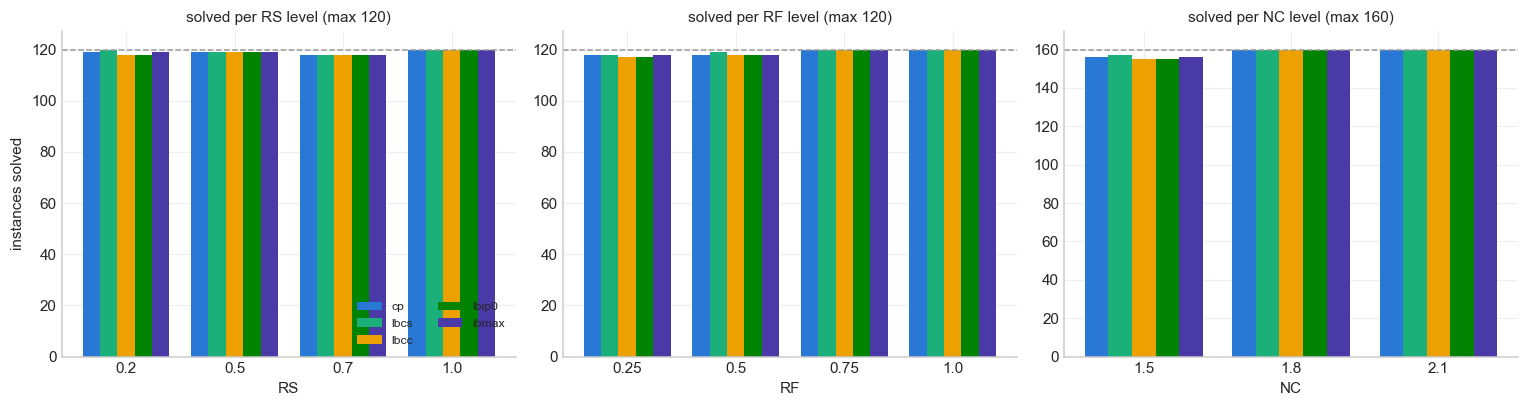

RS         0.2  0.5  0.7  1.0
heuristic                    
cp         119  119  118  120
lbcs       120  119  118  120
lbcc       118  119  118  120
lbip0      118  119  118  120
lbmax      119  119  118  120


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, feat, base in zip(axes, ['RS', 'RF', 'NC'], [120, 120, 160]):
    piv = df[df.solved].groupby(['heuristic', feat]).size().unstack(feat).reindex(HEURISTICS)
    x = np.arange(len(piv.columns)); w = 0.16
    for i, h in enumerate(HEURISTICS):
        bars = ax.bar(x + (i - 2) * w, piv.loc[h], w, color=PALETTE[h], label=h)
    ax.set_xticks(x); ax.set_xticklabels(piv.columns)
    ax.set_xlabel(feat); ax.set_ylim(0, base * 1.06)
    ax.axhline(base, color='#999', lw=1, ls='--')
    ax.set_title(f'solved per {feat} level (max {base})', fontsize=10)
axes[0].set_ylabel('instances solved')
axes[0].legend(fontsize=8, ncol=2, loc='lower right')
plt.tight_layout(); plt.savefig('figures/tt2_solve_by_feature.png', bbox_inches='tight')
plt.show()
print(df[df.solved].groupby(['heuristic','RS']).size().unstack('RS').reindex(HEURISTICS).to_string())

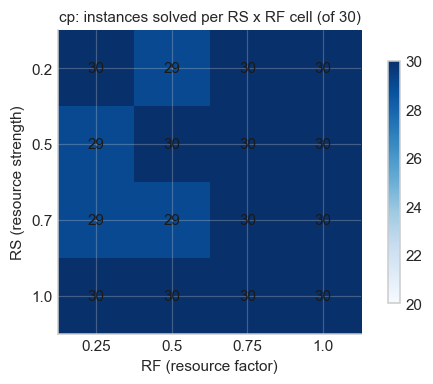

In [4]:
# hardness map: cp solve count per (RS, RF) cell — 30 instances per cell
cp = df[(df.heuristic == 'cp')]
cell = cp[cp.solved].groupby(['RS','RF']).size().unstack('RF').reindex([0.2,0.5,0.7,1.0])
fig, ax = plt.subplots(figsize=(5.2, 3.6))
im = ax.imshow(cell, cmap='Blues', vmin=20, vmax=30)
ax.set_xticks(range(4), [str(c) for c in cell.columns]); ax.set_yticks(range(4), [str(i) for i in cell.index])
ax.set_xlabel('RF (resource factor)'); ax.set_ylabel('RS (resource strength)')
ax.set_title('cp: instances solved per RS x RF cell (of 30)', fontsize=10)
for (r, c), v in np.ndenumerate(cell.values):
    ax.text(c, r, int(v), ha='center', va='center',
            color='white' if v < 25 else '#1a1a19', fontsize=10)
fig.colorbar(im, shrink=0.8)
plt.tight_layout(); plt.savefig('figures/tt2_hardness_map.png', bbox_inches='tight')
plt.show()

## 4. Time analysis — who is faster, and where?

Head-to-head against cp on instances solved by **both**; ratio < 1 means faster than cp.

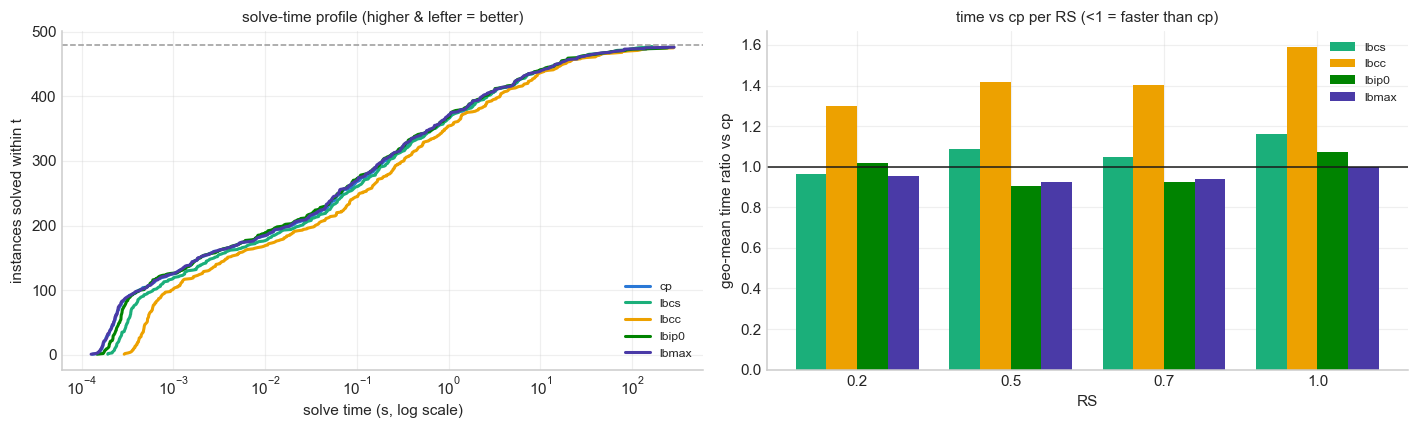

heuristic   lbcs   lbcc  lbip0  lbmax
RS                                   
0.2        0.966  1.300  1.020  0.952
0.5        1.089  1.419  0.905  0.925
0.7        1.047  1.402  0.925  0.941
1.0        1.160  1.589  1.070  0.998


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for h in HEURISTICS:
    t = np.sort(df[(df.heuristic == h) & df.solved].time.values)
    ax.plot(t, np.arange(1, len(t) + 1), color=PALETTE[h], lw=2, label=h)
ax.set_xscale('log'); ax.set_xlabel('solve time (s, log scale)'); ax.set_ylabel('instances solved within t')
ax.axhline(480, color='#999', lw=1, ls='--'); ax.legend(fontsize=8); ax.set_title('solve-time profile (higher & lefter = better)', fontsize=10)

# geo-mean time ratio vs cp, per RS, on commonly-solved instances
cp_t = df[(df.heuristic=='cp') & df.solved].set_index(['group','exam'])['time']
ratio_rows = []
for h in HEURISTICS[1:]:
    d = df[(df.heuristic==h) & df.solved].set_index(['group','exam'])
    common = d.join(cp_t.rename('cp_time'), how='inner')
    common = common[(common.time > 0.1) & (common.cp_time > 0.1)]
    for rs, grp in common.groupby('RS'):
        ratio_rows.append({'heuristic': h, 'RS': rs, 'ratio': geomean(grp.time / grp.cp_time), 'n': len(grp)})
rat = pd.DataFrame(ratio_rows).pivot(index='RS', columns='heuristic', values='ratio')[HEURISTICS[1:]]
ax = axes[1]
x = np.arange(len(rat.index)); w = 0.2
for i, h in enumerate(rat.columns):
    ax.bar(x + (i - 1.5) * w, rat[h], w, color=PALETTE[h], label=h)
ax.axhline(1.0, color='#1a1a19', lw=1)
ax.set_xticks(x); ax.set_xticklabels(rat.index); ax.set_xlabel('RS')
ax.set_ylabel('geo-mean time ratio vs cp'); ax.set_title('time vs cp per RS (<1 = faster than cp)', fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig('figures/tt2_time_analysis.png', bbox_inches='tight')
plt.show()
print(rat.round(3).to_string())

## 5. Node analysis — do the extra bounds actually shrink the search?

Expand-ratio vs cp on commonly-solved instances (a value of 0.9 = 10% fewer nodes than cp), and
the per-node price of computing each bound.

expand-ratio vs cp (geo-mean, common solves with >1000 nodes):
heuristic   lbcs   lbcc  lbip0  lbmax
RS                                   
0.2        0.906  0.956  1.020    1.0
0.5        1.001  0.949  0.896    1.0
0.7        1.001  0.974  0.906    1.0
1.0        0.979  1.000  1.000    1.0


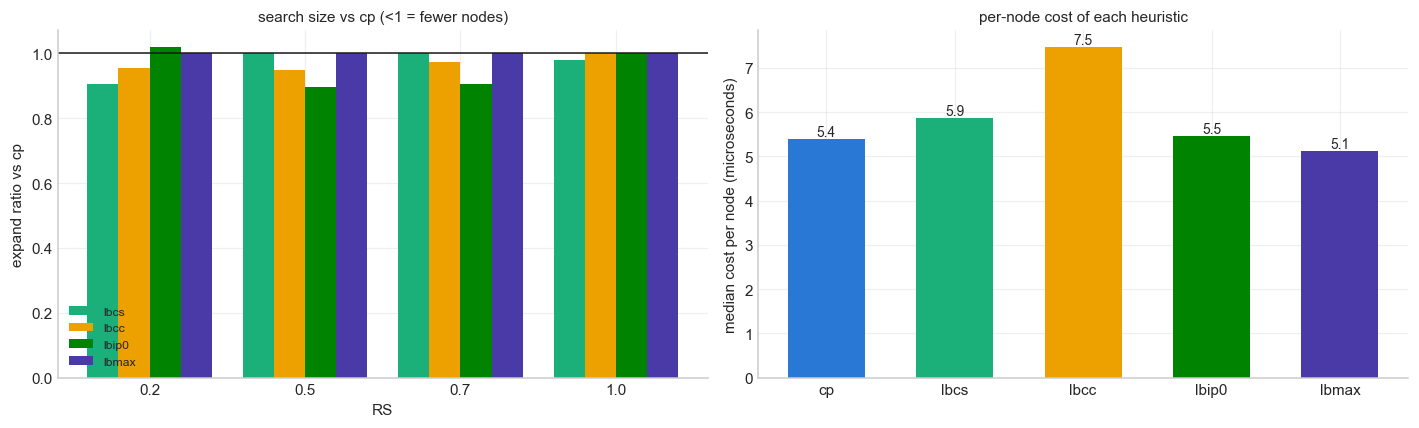

In [6]:
cp_n = df[(df.heuristic=='cp') & df.solved].set_index(['group','exam'])['expand_number']
node_rows = []
for h in HEURISTICS[1:]:
    d = df[(df.heuristic==h) & df.solved].set_index(['group','exam'])
    common = d.join(cp_n.rename('cp_nodes'), how='inner')
    common = common[(common.expand_number > 1000)]
    for rs, grp in common.groupby('RS'):
        node_rows.append({'heuristic': h, 'RS': rs, 'expand ratio': geomean(grp.expand_number / grp.cp_nodes), 'n': len(grp)})
nrat = pd.DataFrame(node_rows).pivot(index='RS', columns='heuristic', values='expand ratio')[HEURISTICS[1:]]
print('expand-ratio vs cp (geo-mean, common solves with >1000 nodes):')
print(nrat.round(3).to_string())

# per-node cost (microseconds per expanded node), median over solved instances > 0.5s
cost = {}
for h in HEURISTICS:
    sv = df[(df.heuristic==h) & df.solved & (df.time > 0.5)]
    cost[h] = (sv.time / sv.expand_number * 1e6).median()
cost = pd.Series(cost).reindex(HEURISTICS)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for i, h in enumerate(nrat.columns):
    ax.bar(np.arange(4) + (i - 1.5) * 0.2, nrat[h], 0.2, color=PALETTE[h], label=h)
ax.axhline(1.0, color='#1a1a19', lw=1); ax.set_xticks(range(4)); ax.set_xticklabels(nrat.index)
ax.set_xlabel('RS'); ax.set_ylabel('expand ratio vs cp'); ax.set_title('search size vs cp (<1 = fewer nodes)', fontsize=10)
ax.legend(fontsize=8)
ax = axes[1]
bars = ax.bar(cost.index, cost.values, color=[PALETTE[h] for h in cost.index], width=0.6)
for b, v in zip(bars, cost.values):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('median cost per node (microseconds)'); ax.set_title('per-node cost of each heuristic', fontsize=10)
plt.tight_layout(); plt.savefig('figures/tt2_node_analysis.png', bbox_inches='tight')
plt.show()

## 6. The hard core — what resists 300 seconds?

Instances that timed out for any heuristic, or needed more than 60s for all of them.

In [7]:
solved_by = df[df.solved].groupby(['group','exam']).heuristic.nunique().rename('n_solvers')
inst = df.pivot_table(index=['group','exam','NC','RF','RS'], columns='heuristic', values='time').reset_index()
inst = inst.merge(solved_by, on=['group','exam'], how='left').fillna({'n_solvers': 0})
hard = inst[(inst.n_solvers < 5) | (inst[HEURISTICS].min(axis=1) > 60)]
hard = hard.sort_values('n_solvers')
timeout_mask = df.pivot_table(index=['group','exam'], columns='heuristic', values='solved', aggfunc='first')
print('instances NOT solved by all 5 heuristics (times in s; >=300 or blank = timeout):')
print(hard.round(1).to_string(index=False))
core4 = inst[inst.n_solvers == 0]
print(f'\nunsolved by every heuristic: {len(core4)} instances')
print(core4[['group','exam','NC','RF','RS']].to_string(index=False))
print('\nfeature signature of the fully-unsolved core: NOT all low-RS —')
print(core4[['RS','RF','NC']].apply(pd.Series.value_counts).fillna(0).astype(int).to_string())

instances NOT solved by all 5 heuristics (times in s; >=300 or blank = timeout):
 group  exam  NC  RF  RS    cp  lbcc  lbcs  lbip0  lbmax  n_solvers
     2     2 1.5 0.2 0.5 300.0 300.0 300.0  300.0  300.0        0.0
     3     9 1.5 0.2 0.7 300.0 300.0 300.0  300.0  300.0        0.0
     7    10 1.5 0.5 0.7 323.7 300.0 300.0  300.0  300.0        0.0
     5     7 1.5 0.5 0.2 300.0 300.0 144.8  300.0  300.0        1.0
     1     4 1.5 0.2 0.2 229.6 300.0 115.5  300.0  286.3        3.0
     3     5 1.5 0.2 0.7 105.4 126.5 105.4  103.0  134.4        5.0
     3    10 1.5 0.2 0.7 141.2 153.6 164.2  180.6  140.0        5.0
     5     3 1.5 0.5 0.2  66.5  77.1  67.9   67.7   67.8        5.0
    10    10 1.5 0.8 0.5 249.8 281.0  93.0  242.8   81.6        5.0
    13     1 1.5 1.0 0.2 142.1 123.9  92.2   88.4   80.5        5.0

unsolved by every heuristic: 3 instances
 group  exam  NC   RF  RS
     2     2 1.5 0.25 0.5
     3     9 1.5 0.25 0.7
     7    10 1.5 0.50 0.7

feature signature of the

## 7. LBCS: damaged run vs clean re-run

The first full LBCS sweep ran all 480 instances in one process; on timeout-heavy stretches its
memory footprint pushed macOS into swap — timeout rows record **500–1100s against a 300s limit**
at ~100x reduced node rates, and borderline instances were suffocated rather than genuinely beaten.
This section quantifies the artifact; re-run the notebook with `LBCS_FILE` pointed at the clean CSV
once that sweep completes.

In [8]:
lb = df[df.heuristic == 'lbcs']
art = lb[lb.swap_artifact]
print(f'lbcs file in use: {FILES["lbcs"]}')
print(f'timeout rows recorded past the 300s limit (swap artifact): {len(art)} of {int((~lb.solved).sum())} timeouts')
if len(art):
    healthy_rate = (lb[lb.solved & (lb.time > 1)].expand_number / lb[lb.solved & (lb.time > 1)].time).median()
    art_rate = (art.expand_number / art.time).median()
    print(f'median node rate: healthy solved rows {healthy_rate/1e3:.0f}K/s vs artifact rows {art_rate/1e3:.1f}K/s '
          f'({healthy_rate/art_rate:.0f}x collapse)')
    print(f'recorded "timeout" durations: {art.time.min():.0f}s to {art.time.max():.0f}s (limit was 300s)')

clean_candidates = [f for f in os.listdir(DATA) if f.endswith('tt2_tt2_full_lbcs_clean.csv')]
if clean_candidates and FILES['lbcs'] != clean_candidates[0]:
    cl = pd.read_csv(DATA + clean_candidates[0], usecols=['group','exam','time','finished'])
    done, sv = len(cl), int((cl.finished == True).sum())
    print(f'\nclean re-run found: {clean_candidates[0]} — {sv} solved / {done} done', '(COMPLETE — flip LBCS_FILE and re-run!)' if done >= 480 else '(still in progress)')
    if done >= 480:
        old_solved = set(map(tuple, lb[lb.solved][['group','exam']].values))
        new_solved = set(map(tuple, cl[cl.finished == True][['group','exam']].values))
        rec = sorted(new_solved - old_solved)
        print(f'instances recovered by the clean run: {len(rec)} -> {rec}')

lbcs file in use: 2026-07-05_j30_g1-48_e1-10_tt2_tt2_full_lbcs_clean.csv
timeout rows recorded past the 300s limit (swap artifact): 0 of 3 timeouts


## 8. Conclusions (final — with the clean LBCS run)

**Final scoreboard: `lbcs` 477 · `cp` 476 · `lbmax` 476 · `lbip0` 475 · `lbcc` 475 (of 480, 300 s limit).**
The chain-based LBCS is the best heuristic — it uniquely solves **g5e7**, an instance every other
configuration times out on. Union across all heuristics = 477; only **g2e2, g3e9, g7e10** resist
everything.

**1. Bounds are near-saturated at ~99%.** `lbmax`'s expand-ratio vs cp is exactly **1.000 at every RS
level** — its bound never exceeds the `max(CP, hres)` floor on j30. `lbcc`/`lbip0` shave 4–10% of
nodes in pockets. Only the chain-LBCS converts its node advantage (~10% at RS 0.2) into extra
coverage — and only by one instance. **Further LB tightening on j30/TT2 is exhausted.**

**2. The classic "low RS = hard" pattern is gone on TT2.** cp solves 119/119/118/120 across RS
levels — flat, where the old TT model collapsed below RS 0.5. The three instances nothing solves have
RS ∈ {0.5, 0.7, 0.7} but **all share RF ≤ 0.5 and NC = 1.5**: few resource types, sparse precedence.
Hardness has migrated from resource *tightness* to scheduling *freedom* (search-tree breadth) — the
right attack is **pruning (upper bounds, dominance), not better bounds**.

**3. Cost/benefit of each bound (vs cp):**
- `lbcs` (chain-based) — **the winner**: ~10% fewer nodes at low RS, modest per-node cost, +1 coverage,
  and (after this project's fix) admissible by construction with node re-opening as the consistency net.
- `lbip0` — free per node, ~10% fewer nodes at mid-RS. Keep.
- `lbmax` — identical search to cp on j30. Value only possible on larger sets (j60+).
- `lbcc` — 27% throughput penalty for 3–5% node savings: net loss (1.3–1.6x slower). Drop or optimize.

**4. Methodology matters as much as theory.** The first lbcs sweep understated it by **49 instances**
(428 vs 477) purely through memory pressure: 50 of its 52 "timeouts" recorded 479–1119 s against a
300 s limit at a 271x collapsed node rate. Identical node counts on commonly-solved instances prove
the search never changed — only the machine did. Benchmark hygiene (fresh process, sequential sweeps,
RAM headroom) is worth more coverage than the choice between any two heuristics.

**5. Next steps.** (a) Upper-bound + dominance pruning aimed at the low-RF/low-NC core (g2e2, g3e9,
g7e10); (b) j60 sweeps with `lbcs` + `cp` + `lbip0`, after vetting each heuristic with `--diagnose`
(j60 has no optimum file to catch inadmissibility).